Computer Vision Based Disease Classfication

In [4]:
# Install required libraries

!pip install -q kagglehub
!pip install -q scikit-learn
!pip install -q seaborn

# Core Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image Processing & Utilities
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

In [5]:
import kagglehub
import os

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

print("Raw Dataset Path:", dataset_path)

# Check folder structure
print("Initial Contents:", os.listdir(dataset_path))

# Fix folder level if nested
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")

print("Final Dataset Path:", dataset_path)
print("Final Contents:", os.listdir(dataset_path))


Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Raw Dataset Path: /kaggle/input/covid19-radiography-database
Initial Contents: ['COVID-19_Radiography_Dataset']
Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


TensorFlow-Only GPU Check



In [6]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    print("GPU is available and will be used automatically by TensorFlow.")
else:
    print("No GPU detected. Running on CPU.")

TensorFlow Version: 2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and will be used automatically by TensorFlow.



Dataset Path Verification Block


In [7]:

print("Verifying dataset path...\n")
print("Dataset Path:", dataset_path)

# List all items
items = os.listdir(dataset_path)
print("\nAll items inside dataset folder:")
for item in items:
    print(" -", item)

# Detect only directories (class folders)
class_folders = [
    folder for folder in items
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("\nDetected class folders:")
for folder in class_folders:
    print(" -", folder)

print("\nNumber of class folders detected:", len(class_folders))


Verifying dataset path...

Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset

All items inside dataset folder:
 - Lung_Opacity.metadata.xlsx
 - Normal.metadata.xlsx
 - README.md.txt
 - COVID.metadata.xlsx
 - Normal
 - Lung_Opacity
 - Viral Pneumonia.metadata.xlsx
 - Viral Pneumonia
 - COVID

Detected class folders:
 - Normal
 - Lung_Opacity
 - Viral Pneumonia
 - COVID

Number of class folders detected: 4


Image Transform / Preprocessing Block

In [8]:
# Minimal TF prep: split + normalize to [0,1] (no extra imports)

img_size = (224, 224)
batch_size = 32
val_split = 0.2
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=val_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=val_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    color_mode='grayscale'
)

normalizer = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Keep transform for the downstream torchvision ImageFolder block
transform = None

Found 42330 files belonging to 4 classes.
Using 33864 files for training.
Found 42330 files belonging to 4 classes.
Using 8466 files for validation.


Verify sample images (first 25 from training set)



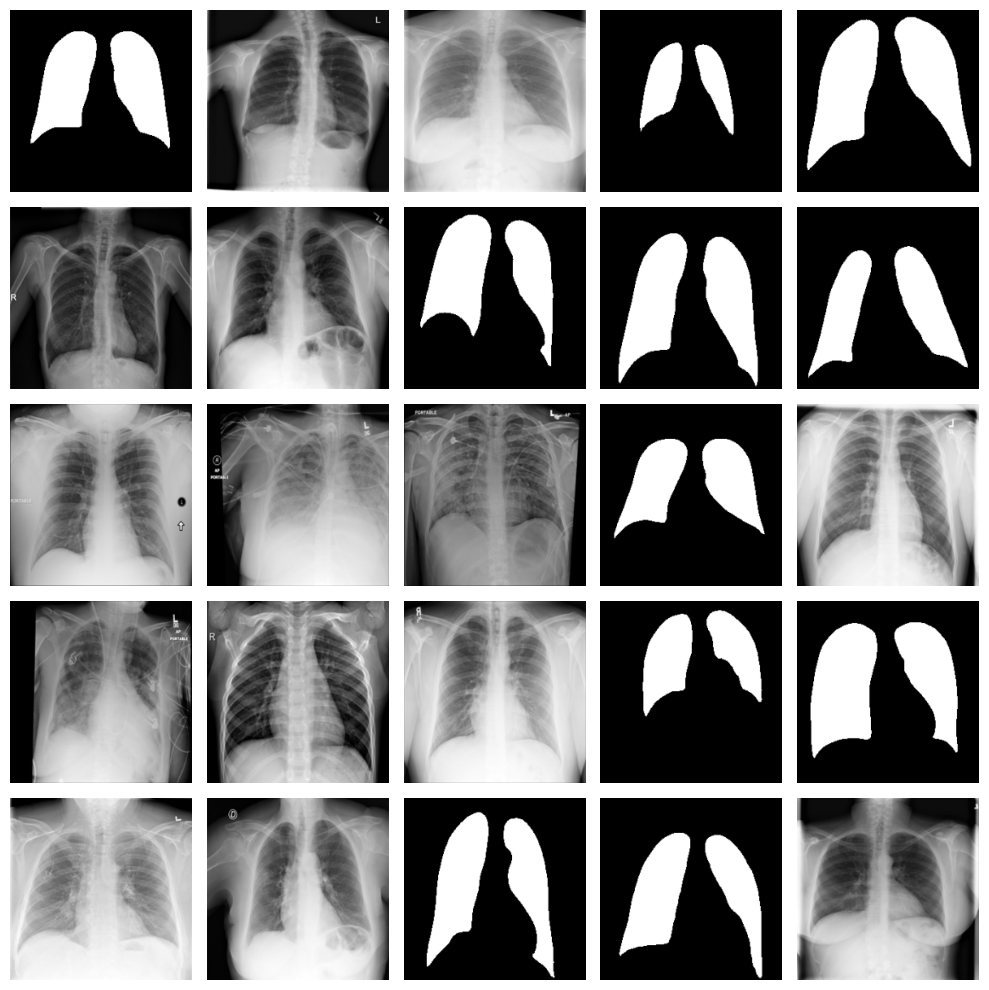

In [9]:
# Get one batch safely
batch_images, batch_labels = next(iter(train_ds))

# If class_names was lost after .map(), define manually
try:
    class_names
except NameError:
    class_names = train_ds.class_names if hasattr(train_ds, "class_names") else None

# Plot first 25 images
plt.figure(figsize=(10, 10))

for i in range(min(25, batch_images.shape[0])):
    ax = plt.subplot(5, 5, i + 1)

    img = batch_images[i].numpy()

    # Handle grayscale properly
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img)

    if class_names is not None:
        label_idx = int(batch_labels[i].numpy())
        plt.title(class_names[label_idx], fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
conv_base = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
conv_base.add(layers.Flatten())
conv_base.add(layers.Dense(128, activation='relu'))
conv_base.add(layers.Dropout(0.5))   # important for medical dataset
conv_base.add(layers.Dense(4, activation='softmax'))

In [13]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,900 (42.61 MB)

 Trainable params: 11,168,900 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
conv_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = conv_base.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 172s 155ms/step - accuracy: 0.5598 - loss: 1.0271 - val_accuracy: 0.7211 - val_loss: 0.7059
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 54s 51ms/step - accuracy: 0.7083 - loss: 0.7242 - val_accuracy: 0.7531 - val_loss: 0.6245
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.7468 - loss: 0.6321 - val_accuracy: 0.7745 - val_loss: 0.5666
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 54s 51ms/step - accuracy: 0.7749 - loss: 0.5660 - val_accuracy: 0.7746 - val_loss: 0.5701
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 54s 51ms/step - accuracy: 0.7951 - loss: 0.5120 - val_accuracy: 0.7825 - val_loss: 0.5675
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.8157 - loss: 0.4676 - val_accuracy: 0.7918 - val_loss: 0.5637
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.8304 - loss: 0.4175 - val_accuracy: 0.7869 - val_loss: 0.5852
Epoch 8/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.8463

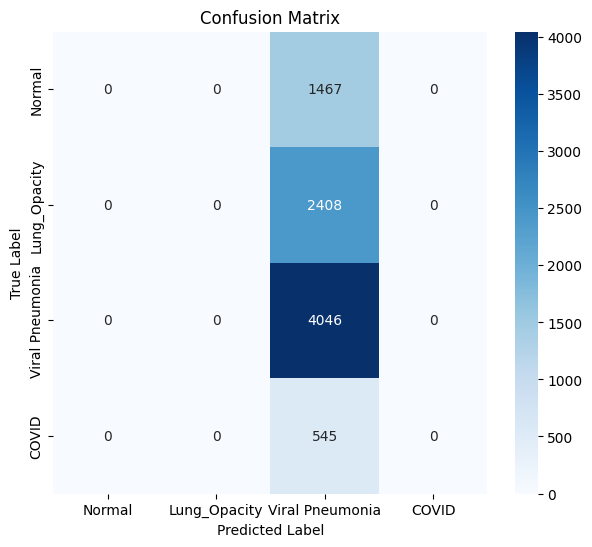

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use the already existing class_folders variable
class_names = class_folders

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Create plots of the loss and accuracy on the training and validation sets:




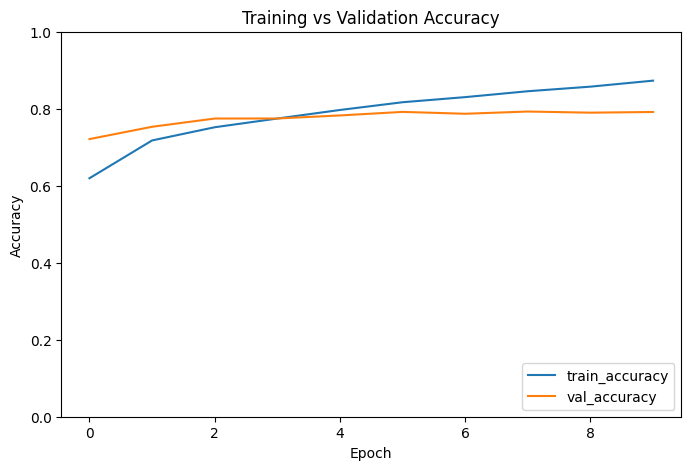

265/265 - 3s - 11ms/step - accuracy: 0.7915 - loss: 0.6885

Validation Accuracy: 0.791519045829773


In [15]:
# Plot training vs validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0,1])

plt.legend(loc='lower right')
plt.title("Training vs Validation Accuracy")

plt.show()


# Evaluate model on validation dataset

val_loss, val_acc = conv_base.evaluate(val_ds, verbose=2)

print("\nValidation Accuracy:", val_acc)

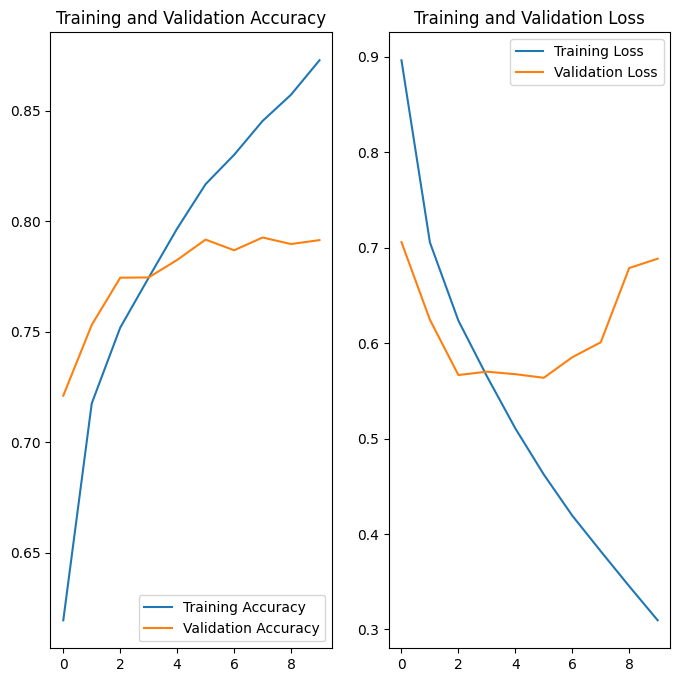

In [16]:
# Get metrics from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Number of epochs
epochs_range = range(len(acc))

plt.figure(figsize=(8,8))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(224, 224, 1)),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


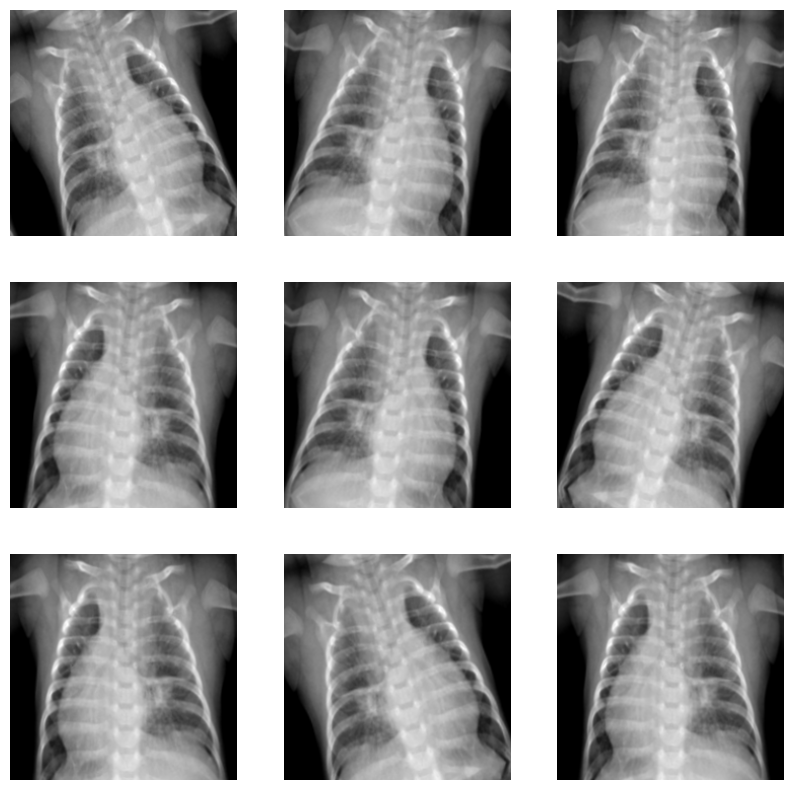

In [18]:
plt.figure(figsize=(10,10))

for images, _ in train_ds.take(1):

    for i in range(9):

        augmented_images = data_augmentation(images)

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            augmented_images[0].numpy().squeeze(),
            cmap="gray"
        )

        plt.axis("off")

plt.show()

In [19]:
model = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255, input_shape=(224,224,1)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(4, activation='softmax')
])

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,468 (24.59 MB)

 Trainable params: 6,446,468 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y = []
for _, labels in train_ds:
    y.extend(labels.numpy())

y = np.array(y)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

class_weights = {i: w for i, w in enumerate(weights)}
print(class_weights)

{0: np.float64(1.4685169124024284), 1: np.float64(0.8804076539101497), 2: np.float64(0.5181784796180683), 3: np.float64(3.946853146853147)}


In [31]:
epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 2/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 3/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 4/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 5/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 6/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 7/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - accuracy: 0.4813 - loss: 1.1870 - val_accuracy: 0.4779 - val_loss: 1.1912
Epoch 8/15
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.4813 -

KeyboardInterrupt: 

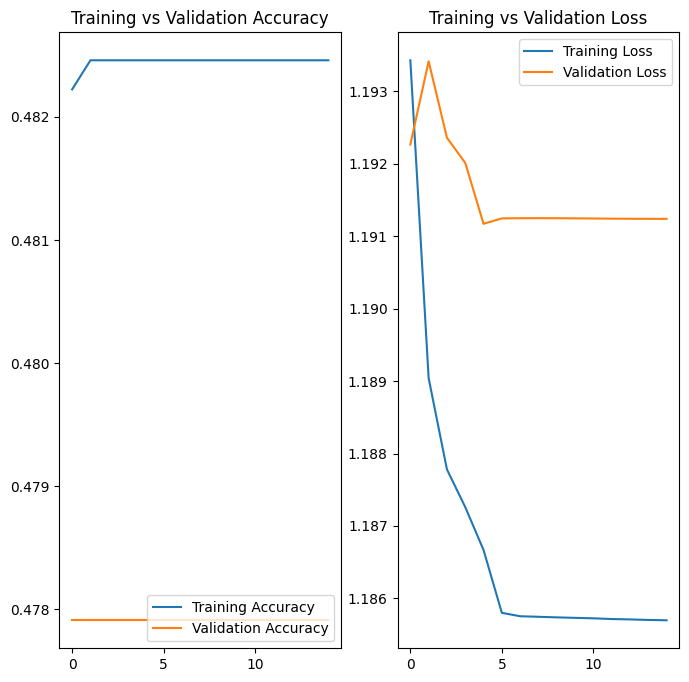

In [23]:
# Extract metrics from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Create epoch range
epochs_range = range(len(acc))

plt.figure(figsize=(8,8))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.show()

In [24]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_pred.extend(predicted_labels)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[   0    0 1467    0]
 [   0    0 2408    0]
 [   0    0 4046    0]
 [   0    0  545    0]]


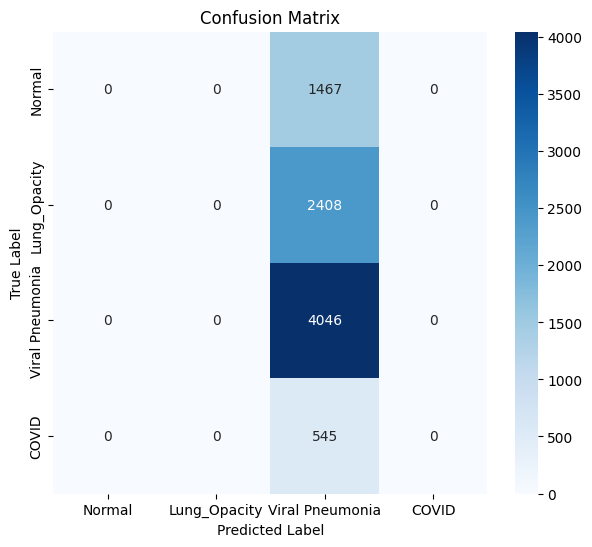

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use the already existing class_folders variable
class_names = class_folders

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [28]:
import os
from collections import Counter

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))

print("Dataset distribution:\n")

for k, v in class_counts.items():
    print(f"{k}: {v}")

Dataset distribution:

Normal: 2
Lung_Opacity: 2
Viral Pneumonia: 2
COVID: 2


In [29]:
import os

class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images_path = os.path.join(class_path, "images")

        if os.path.exists(images_path):
            num_images = len(os.listdir(images_path))
            class_counts[class_name] = num_images

print("Correct dataset distribution:\n")

for k,v in class_counts.items():
    print(f"{k}: {v}")

Correct dataset distribution:

Normal: 10192
Lung_Opacity: 6012
Viral Pneumonia: 1345
COVID: 3616
